# ================================================
# Notebook 03 — Feature Engineering & Engagement Scoring
# Project: Ad Engagement Analysis
# Goal: Build a custom business metric to rank ad effectiveness
# ================================================

In this notebook, we move beyond just counting interactions. We are going to build a custom **Engagement Effectiveness Score**.

### The Business Logic:
Not all interactions are equal.
- Base Comment = **1 point** (Minimum effort)
- Emoji Used = **+2 points** (Shows active emotional reaction)
- Hashtags Used = **+1 point per hashtag** (Shows intent to amplify/share the ad visually)

Combining these gives us a weighted score, allowing us to find the campaigns that truly performed the best!

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

# Load and clean the dataset
df = pd.read_csv('../data/comments_cleaned.csv')

if 'Unnamed: 0' in df.columns:
    df.drop('Unnamed: 0', axis=1, inplace=True)
if 'id' in df.columns:
    df.drop('id', axis=1, inplace=True)
    
df.rename(columns={
    'User  id': 'user_id',
    'Photo id': 'campaign_id',
    'created Timestamp': 'timestamp',
    'posted date': 'posted_date',
    'emoji used': 'emoji_used',
    'Hashtags used count': 'hashtag_count'
}, inplace=True)

print("Data loaded successfully.")

Data loaded successfully.


In [ ]:
# 1. Feature Engineering: The Engagement Score
# Create the individual components
df['base_comment_score'] = 1
df['emoji_score'] = df['emoji_used'].apply(lambda x: 2 if x == 'yes' else 0)
# hashtag_count is already an integer from 0 to 6

# Calculate Total Score
df['engagement_score'] = df['base_comment_score'] + df['emoji_score'] + df['hashtag_count']

# Let's see some extremely high vs low engagement comments
print("Sample of scored interactions:")
df[['campaign_id', 'comment', 'emoji_used', 'hashtag_count', 'engagement_score']].sample(5, random_state=42)

Sample of scored interactions:


,campaign_id,comment,emoji_used,hashtag_count,engagement_score
4784,164,ea voluptatem mollitia,no,6,7
3595,125,omnis sunt odio,no,5,6
6812,233,dolores assumenda perspiciatis,no,6,7
3589,125,aliquid ex aut,no,2,3
6450,221,nihil modi perspiciatis,yes,0,3


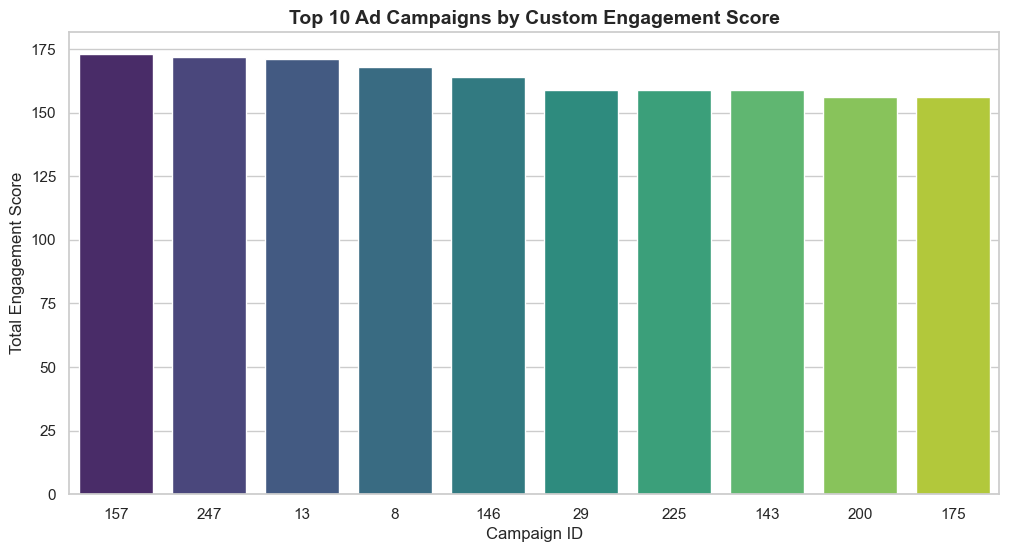

In [3]:
# 2. Campaign Level Performance
# Let's aggregate these individual scores to the campaign level!

campaign_performance = df.groupby('campaign_id').agg(
    total_interactions=('user_id', 'count'),
    total_engagement_score=('engagement_score', 'sum'),
    avg_engagement_score=('engagement_score', 'mean')
).reset_index()

# Sort to find the highest-performing campaigns based on true engagement
top_campaigns = campaign_performance.sort_values(by='total_engagement_score', ascending=False).head(10)

plt.figure(figsize=(12, 6))
# Create a bar plot using the new custom metric
sns.barplot(
    data=top_campaigns, 
    x=top_campaigns['campaign_id'].astype(str), 
    y='total_engagement_score', 
    palette='viridis'
)
plt.title('Top 10 Ad Campaigns by Custom Engagement Score', fontsize=14, fontweight='bold')
plt.xlabel('Campaign ID')
plt.ylabel('Total Engagement Score')
plt.show()

In [5]:
# 3. Save Final Analytical Data to CSV
# We will need these enriched data files to power the Streamlit Dashboard (Day 5)

# Save the user-interaction level data with scores
df.to_csv('../data/ad_interactions_scored.csv', index=False)

# Save the campaign-level aggregated performance metrics
campaign_performance.to_csv('../data/campaign_performance.csv', index=False)

print(" Feature Engineered datasets successfully saved to /data folder!")

 Feature Engineered datasets successfully saved to /data folder!


In [7]:
# 4. Quick Validation Checks
required_columns = ['campaign_id', 'comment', 'emoji_used', 'hashtag_count', 'engagement_score']

# Check for missing required columns
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    print(f"Missing required columns: {missing_columns}")
else:
    print("All required columns are present.")

# Validate emoji values used by scoring logic
allowed_emoji_values = {'yes', 'no'}
emoji_series = df['emoji_used']
emoji_normalized = emoji_series.dropna().astype(str).str.strip().str.lower()
invalid_emoji_values = sorted(set(emoji_normalized.unique()) - allowed_emoji_values)
null_emoji_count = int(emoji_series.isna().sum())

if invalid_emoji_values:
    print(f"Unexpected emoji_used values found: {invalid_emoji_values}")
else:
    print("emoji_used values are valid (yes/no only).")

if null_emoji_count > 0:
    print(f"Warning: emoji_used has {null_emoji_count} missing values.")

# Engagement score min/max sanity check
score_min = df['engagement_score'].min()
score_max = df['engagement_score'].max()
print(f"Engagement score range: min={score_min}, max={score_max}")

# Validate exported row counts against in-memory DataFrames
ad_interactions_export = pd.read_csv('../data/ad_interactions_scored.csv')
campaign_performance_export = pd.read_csv('../data/campaign_performance.csv')

print(
    f"ad_interactions_scored.csv rows: {len(ad_interactions_export)} (expected {len(df)})"
)
print(
    f"campaign_performance.csv rows: {len(campaign_performance_export)} (expected {len(campaign_performance)})"
)

if len(ad_interactions_export) == len(df) and len(campaign_performance_export) == len(campaign_performance):
    print("Export row-count validation passed.")
else:
    print("Export row-count validation failed.")

All required columns are present.
emoji_used values are valid (yes/no only).
Engagement score range: min=3, max=7
ad_interactions_scored.csv rows: 7488 (expected 7488)
campaign_performance.csv rows: 257 (expected 257)
Export row-count validation passed.
